# Reading NetCDF File for Oregon Location 1 (Complete Dataset)

This notebook demonstrates how to:
1. Load the complete Oregon Location 1 NetCDF dataset (`CMVoregonloc1complete.nc`)
2. Convert it into a Pandas DataFrame and calculate current velocity (`speed` in cm/s) and `direction` (in degrees)
3. Display summary statistics and visualize distributions for the entire dataset, including physical (speed, direction) and environmental (salinity, temperature) variables
4. Plot monthly distributions of speed, direction, salinity, and temperature across all 48 months in the dataset
5. Subset the dataset into years (`year1`, `year2`, `year3`, and an 11-month `year4`) starting from the initial timestamp
6. Display summary statistics and visualize distributions for individual years

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load the NetCDF file
We use `xarray.open_dataset` to load the `CMVoregonloc1complete.nc` file efficiently.

In [2]:
nc_file = 'CMVoregonloc1complete.nc'
ds = xr.open_dataset(nc_file)
ds

<xarray.Dataset> Size: 28MB
Dimensions:    (time: 34345, depth: 1, latitude: 10, longitude: 5)
Coordinates:
  * time       (time) datetime64[ns] 275kB 2022-07-04T12:00:00 ... 2026-06-04...
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 40B 45.33 45.42 45.5 ... 45.92 46.0 46.08
  * longitude  (longitude) float32 20B -124.4 -124.3 -124.2 -124.2 -124.1
Data variables:
    uo         (time, depth, latitude, longitude) float32 7MB ...
    vo         (time, depth, latitude, longitude) float32 7MB ...
    so         (time, depth, latitude, longitude) float32 7MB ...
    thetao     (time, depth, latitude, longitude) float32 7MB ...
Attributes:
    Conventions:       CF-1.11
    title:             hourly mean fields from Global Ocean Physics Analysis ...
    institution:       Mercator Ocean International
    producer:          CMEMS - Global Monitoring and Forecasting Centre
    source:            MOI GLO12
    credit:            E.U. Copernicus Marine Service Information (CMEMS)
    contact:           https://marine.copernicus.eu/contact
    references:        http://marine.copernicus.eu
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  GLOBAL_ANALYSISFORECAST_PHY_001_024
    subset:datasetId:  cmems_mod_glo_phy_anfc_0.083deg_PT1H-m_202406
    subset:date:       2026-06-03T22:27:08.830Z

### 2. Convert to DataFrame and Calculate Velocity/Direction
We convert the dataset to a Pandas DataFrame, reset its index, and immediately compute the current speed (scaled to **cm/s**) and direction (in degrees relative to North).

In [3]:
# Convert to DataFrame
df = ds.to_dataframe().reset_index()

# 1. Calculate Vector Magnitude (Sea Water Speed) in m/s
df['speed'] = np.sqrt(df['uo']**2 + df['vo']**2)

# 2. Convert Speed to cm/s for clean integer ticks on x-axis
df['speed_cms'] = df['speed'] * 100

# 3. Calculate Vector Direction in Degrees (Oceanographic convention: 0° = North, 90° = East)
sea_water_dir = np.degrees(np.arctan2(df['uo'], df['vo']))
df['direction'] = (sea_water_dir + 360) % 360  # Ensure all values are 0-360°

print('DataFrame loaded and calculations complete!')
df[['time', 'latitude', 'longitude', 'uo', 'vo', 'speed_cms', 'direction', 'so', 'thetao']].head()

DataFrame loaded and calculations complete!


,time,latitude,longitude,uo,vo,speed_cms,direction,so,thetao
0,2022-07-04 12:00:00,45.333332,-124.416664,-0.043134,-0.047326,6.403319,222.347046,27.711361,15.829979
1,2022-07-04 12:00:00,45.333332,-124.333328,-0.088708,-0.191485,21.103456,204.856461,27.671654,15.372473
2,2022-07-04 12:00:00,45.333332,-124.250000,-0.129235,-0.389177,41.007408,198.369949,27.566126,14.521750
3,2022-07-04 12:00:00,45.333332,-124.166664,-0.144952,-0.561691,58.009266,194.470291,27.759602,14.093076
4,2022-07-04 12:00:00,45.333332,-124.083328,-0.140565,-0.566816,58.398582,193.927887,28.271833,13.075114


### 3. Inspect DataFrame Info & Summary Statistics (Entire Dataset)
View structural info and statistical summaries for physical and environmental variables across the entire dataset.

In [4]:
print('--- DataFrame Info ---')
df.info()

print('\n--- Summary Statistics (Entire Dataset) ---')
display(df[['uo', 'vo', 'speed_cms', 'direction', 'so', 'thetao']].describe())

--- DataFrame Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1717250 entries, 0 to 1717249
Data columns (total 11 columns):
 #   Column     Dtype         
---  ------     -----         
 0   time       datetime64[ns]
 1   depth      float32       
 2   latitude   float32       
 3   longitude  float32       
 4   uo         float32       
 5   vo         float32       
 6   so         float32       
 7   thetao     float32       
 8   speed      float32       
 9   speed_cms  float32       
 10  direction  float32       
dtypes: datetime64[ns](1), float32(10)
memory usage: 78.6 MB

--- Summary Statistics (Entire Dataset) ---


,uo,vo,speed_cms,direction,so,thetao
count,1.717250e+06,1.717250e+06,1.717250e+06,1.717250e+06,1.717250e+06,1.717250e+06
mean,-1.089330e-02,-2.881921e-02,2.231161e+01,1.823128e+02,3.070917e+01,1.202240e+01
std,1.031531e-01,2.360813e-01,1.324512e+01,1.053839e+02,1.328815e+00,2.043166e+00
min,-7.679984e-01,-1.004955e+00,1.606959e-02,9.155273e-05,2.606624e+01,6.976470e+00
25%,-7.752463e-02,-1.906826e-01,1.236296e+01,1.124979e+02,2.973732e+01,1.065957e+01
50%,-1.075414e-02,-3.207959e-02,1.995459e+01,1.858498e+02,3.082238e+01,1.176088e+01
75%,5.541153e-02,1.321160e-01,2.981790e+01,2.508817e+02,3.192820e+01,1.335410e+01
max,6.329804e-01,1.024583e+00,1.025240e+02,3.599999e+02,3.351308e+01,1.928720e+01


### 4. Visualize Distributions (Entire Dataset)
Plot a 2x2 grid of histograms with clean integer tick marks and correct units for Speed, Direction, Salinity, and Temperature.

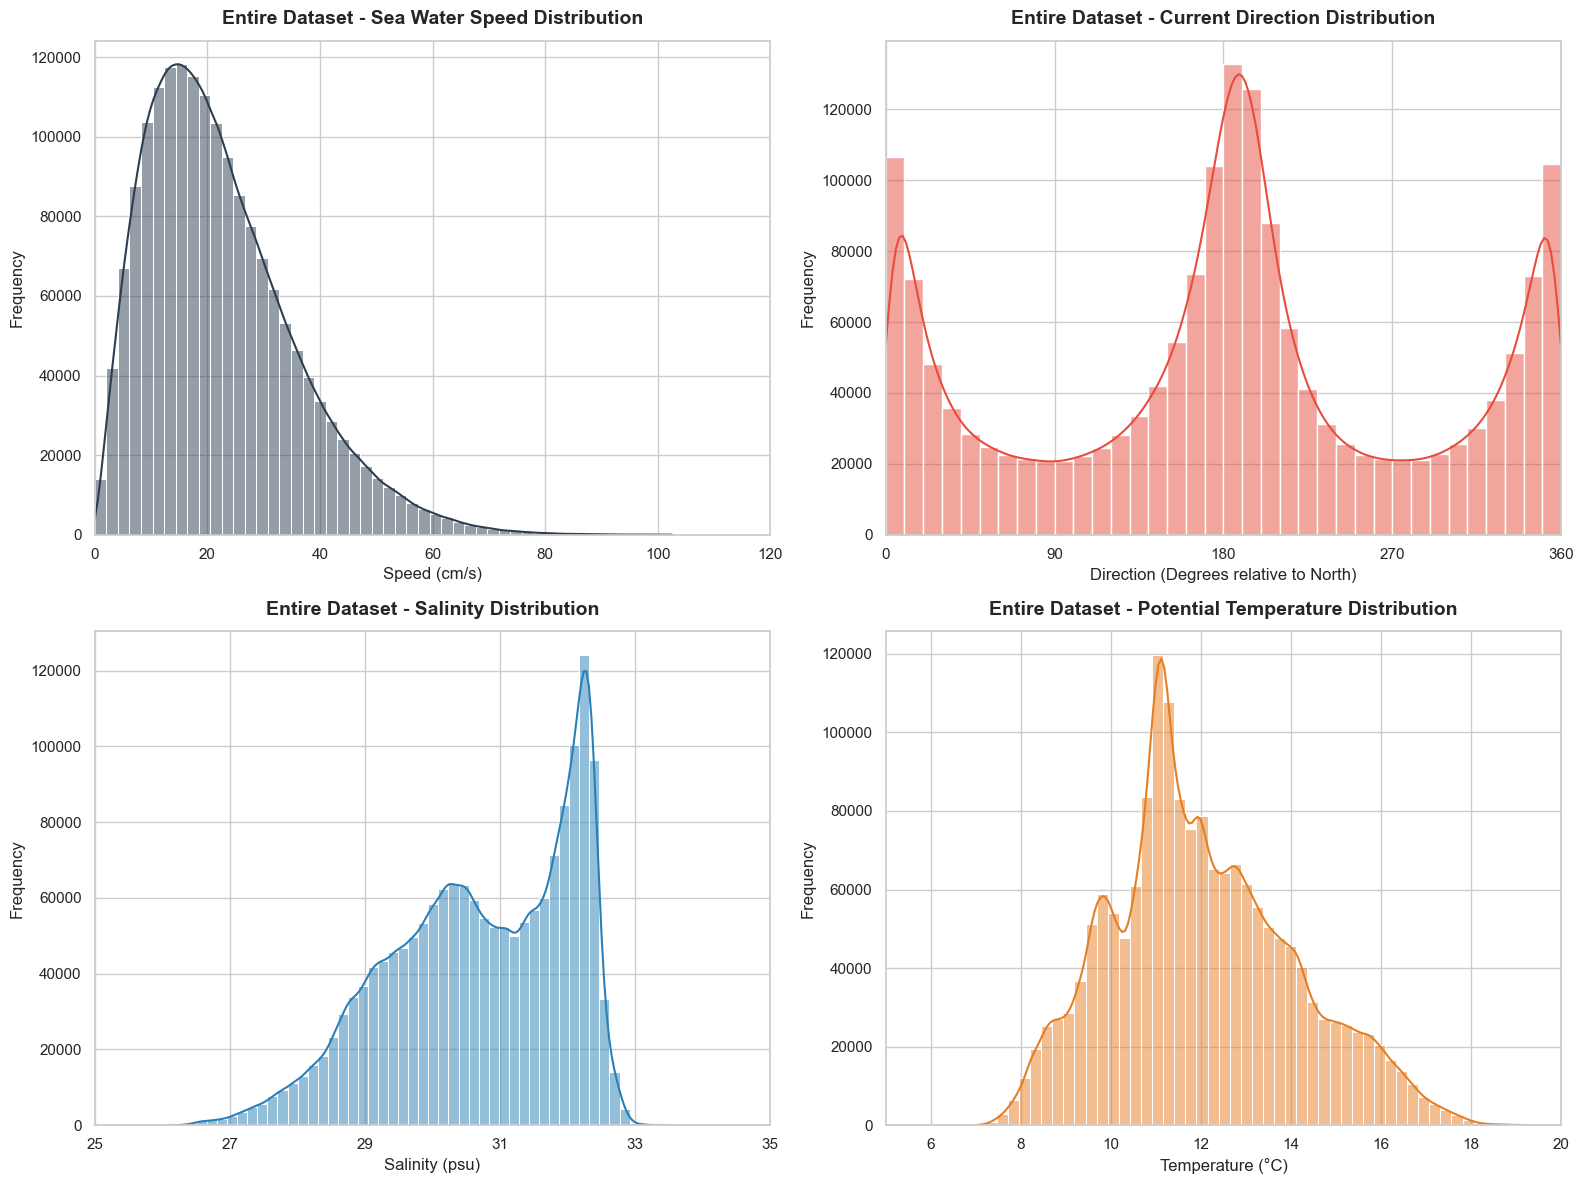

In [5]:
# Set visual style
sns.set_theme(style='whitegrid')

# Create 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Speed Histogram
sns.histplot(data=df, x='speed_cms', bins=50, kde=True, ax=axes[0, 0], color='#2c3e50')
axes[0, 0].set_title('Entire Dataset - Sea Water Speed Distribution', fontsize=14, fontweight='bold', pad=12)
axes[0, 0].set_xlabel('Speed (cm/s)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_xlim(0, 110)
axes[0, 0].set_xticks([0, 20, 40, 60, 80, 100, 120])

# 2. Direction Histogram
sns.histplot(data=df, x='direction', bins=36, kde=True, ax=axes[0, 1], color='#e74c3c')
axes[0, 1].set_title('Entire Dataset - Current Direction Distribution', fontsize=14, fontweight='bold', pad=12)
axes[0, 1].set_xlabel('Direction (Degrees relative to North)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_xlim(0, 360)
axes[0, 1].set_xticks([0, 90, 180, 270, 360])

# 3. Salinity Histogram
sns.histplot(data=df, x='so', bins=50, kde=True, ax=axes[1, 0], color='#2980b9')
axes[1, 0].set_title('Entire Dataset - Salinity Distribution', fontsize=14, fontweight='bold', pad=12)
axes[1, 0].set_xlabel('Salinity (psu)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_xlim(25, 35)
axes[1, 0].set_xticks([25, 27, 29, 31, 33, 35])

# 4. Temperature Histogram
sns.histplot(data=df, x='thetao', bins=50, kde=True, ax=axes[1, 1], color='#e67e22')
axes[1, 1].set_title('Entire Dataset - Potential Temperature Distribution', fontsize=14, fontweight='bold', pad=12)
axes[1, 1].set_xlabel('Temperature (°C)', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_xlim(5, 20)
axes[1, 1].set_xticks([6, 8, 10, 12, 14, 16, 18, 20])

plt.tight_layout()
plt.show()

### 5. Monthly Distribution (Entire Dataset)
Box plots of Speed, Direction, Salinity, and Temperature grouped by calendar month to show seasonal trends chronologically across all 48 months.

C:\Users\chris\AppData\Local\Temp\ipykernel_42084\3208456038.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='year_month', y='speed_cms', ax=axes[0], palette='crest', order=sorted_months)
C:\Users\chris\AppData\Local\Temp\ipykernel_42084\3208456038.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
C:\Users\chris\AppData\Local\Temp\ipykernel_42084\3208456038.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='year_month', y='direction', ax=axes[1], palette='flare', order=sorted_months)
C:\Users\chris\Ap

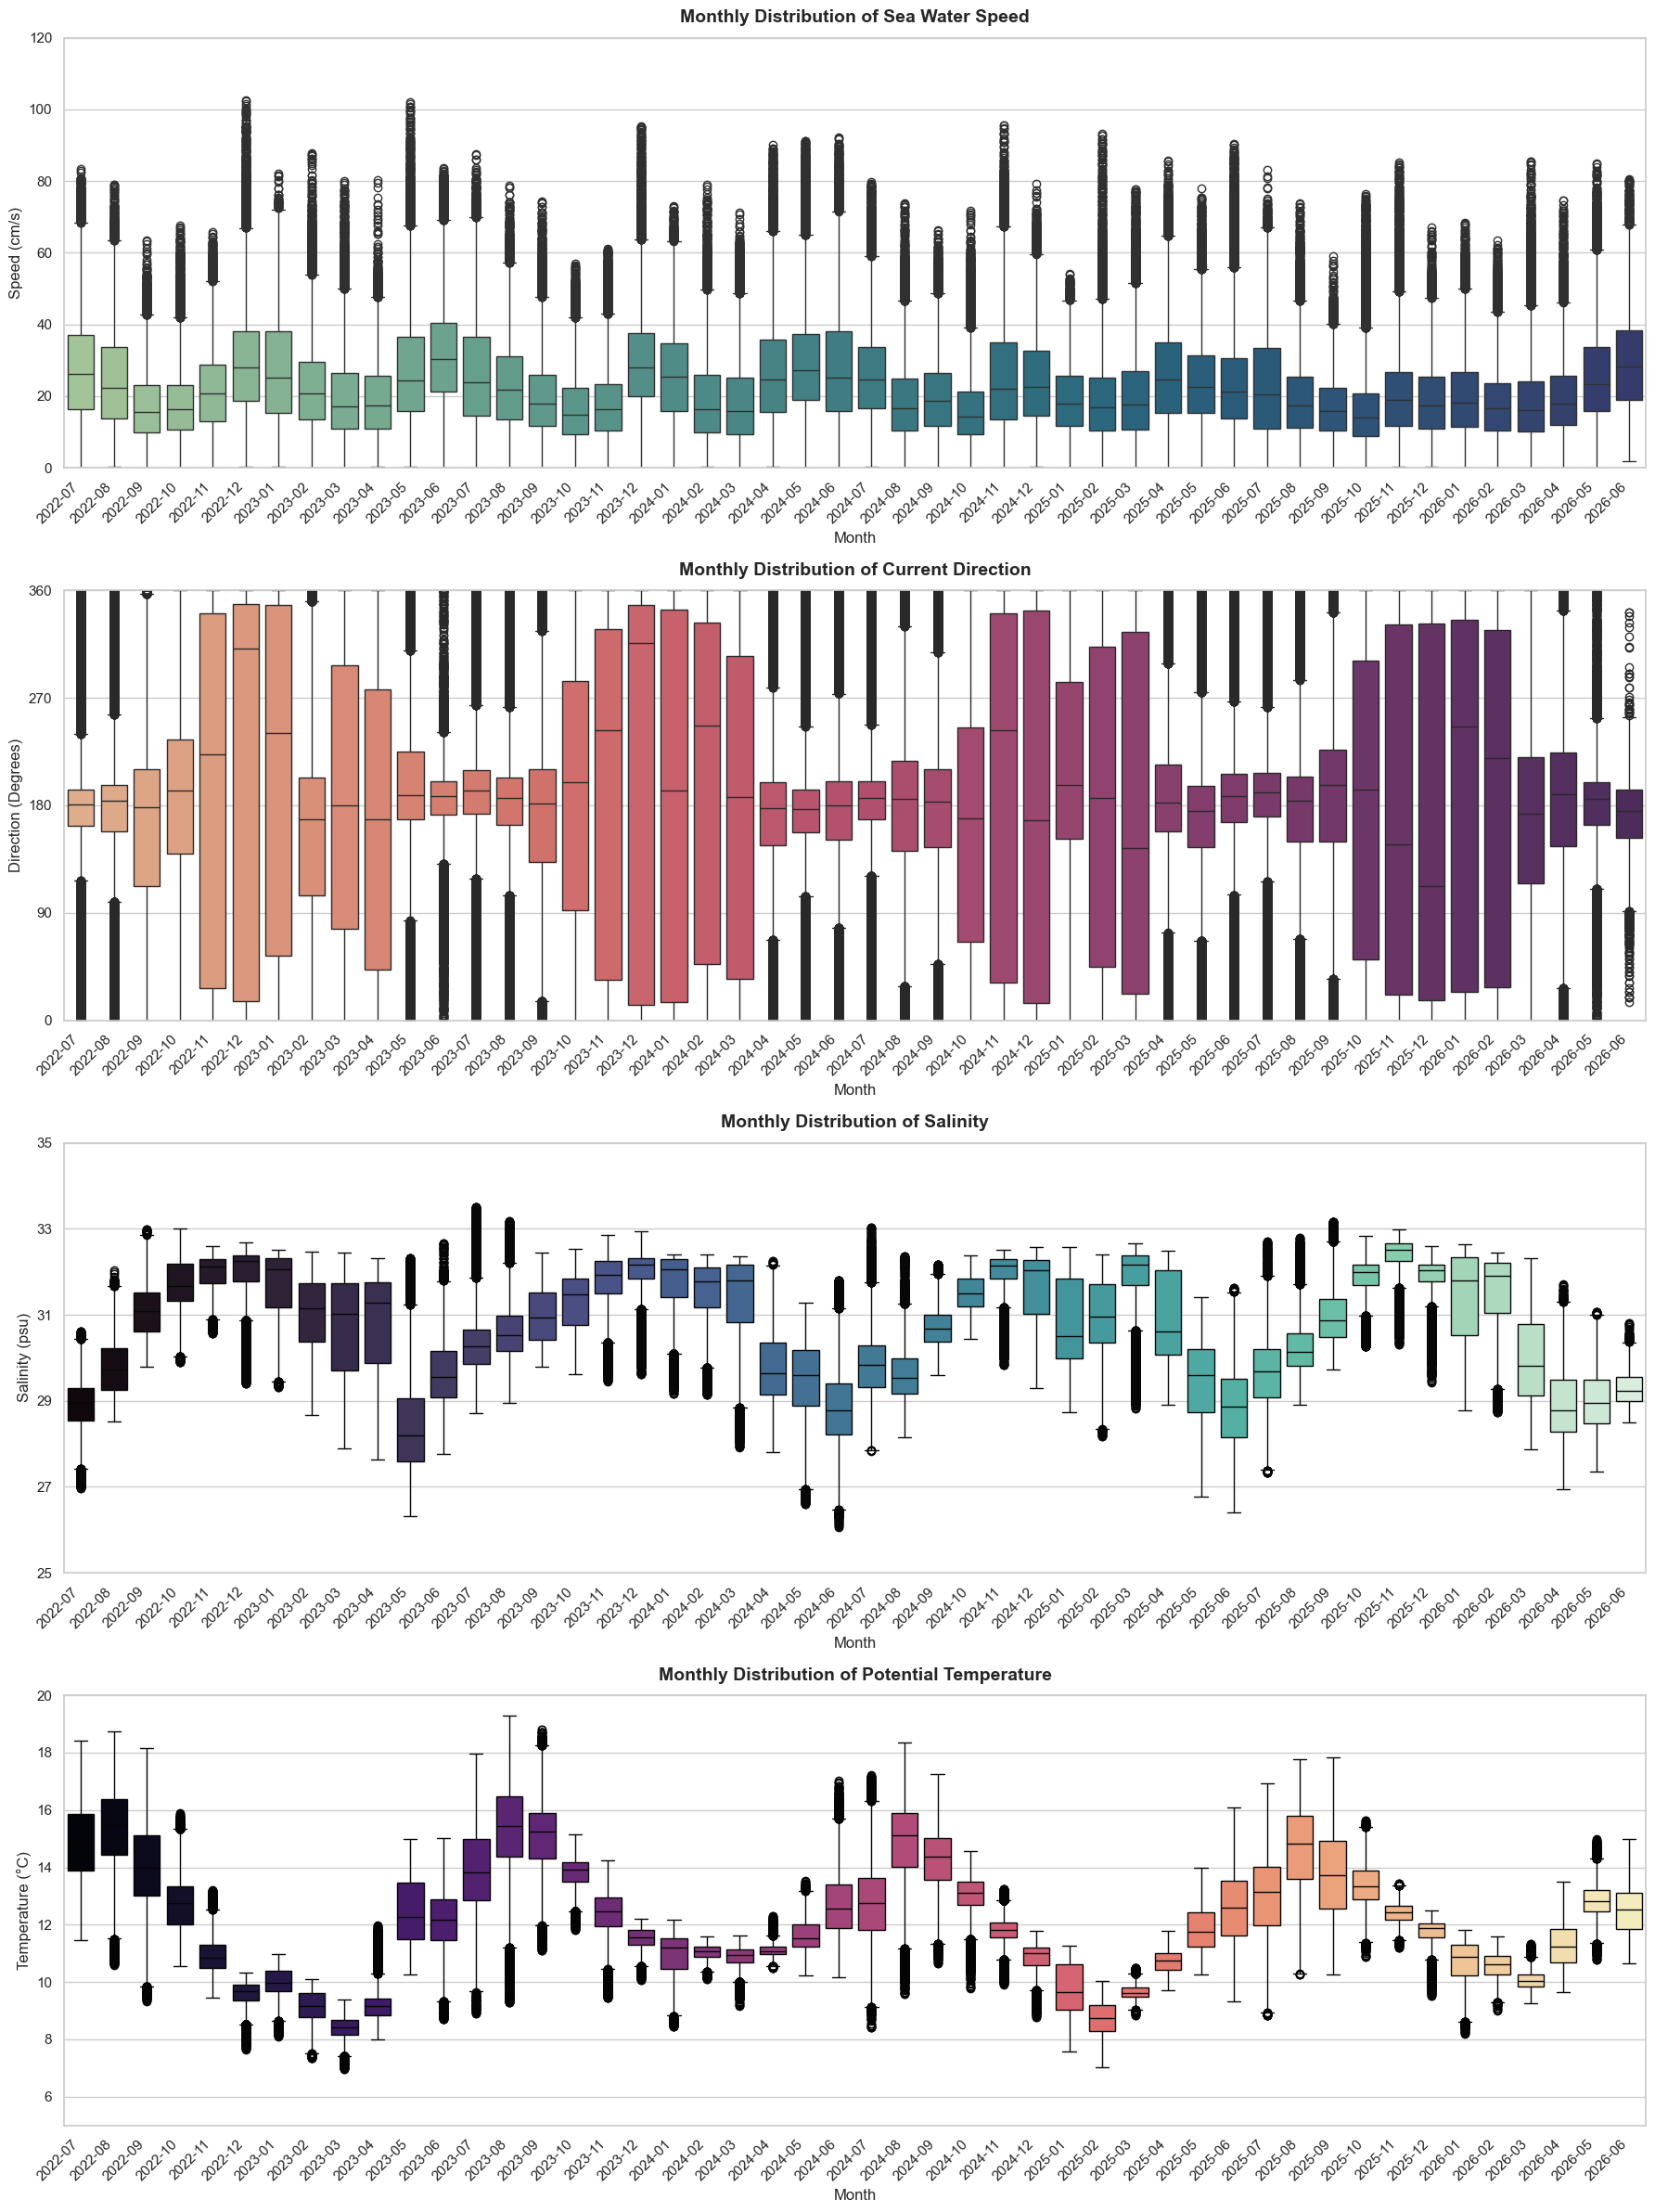

In [6]:
# Create sorted Year-Month string column for grouping
df['year_month'] = df['time'].dt.strftime('%Y-%m')
sorted_months = sorted(df['year_month'].unique())

# Setup figure with 4 vertical subplots
fig, axes = plt.subplots(4, 1, figsize=(18, 24))

# 1. Speed Boxplot
sns.boxplot(data=df, x='year_month', y='speed_cms', ax=axes[0], palette='crest', order=sorted_months)
axes[0].set_title('Monthly Distribution of Sea Water Speed', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Month', fontsize=12)
axes[0].set_ylabel('Speed (cm/s)', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylim(0, 110)
axes[0].set_yticks([0, 20, 40, 60, 80, 100, 120])

# 2. Direction Boxplot
sns.boxplot(data=df, x='year_month', y='direction', ax=axes[1], palette='flare', order=sorted_months)
axes[1].set_title('Monthly Distribution of Current Direction', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Month', fontsize=12)
axes[1].set_ylabel('Direction (Degrees)', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylim(0, 360)
axes[1].set_yticks([0, 90, 180, 270, 360])

# 3. Salinity Boxplot
sns.boxplot(data=df, x='year_month', y='so', ax=axes[2], palette='mako', order=sorted_months)
axes[2].set_title('Monthly Distribution of Salinity', fontsize=14, fontweight='bold', pad=12)
axes[2].set_xlabel('Month', fontsize=12)
axes[2].set_ylabel('Salinity (psu)', fontsize=12)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')
axes[2].set_ylim(25, 35)
axes[2].set_yticks([25, 27, 29, 31, 33, 35])

# 4. Temperature Boxplot
sns.boxplot(data=df, x='year_month', y='thetao', ax=axes[3], palette='magma', order=sorted_months)
axes[3].set_title('Monthly Distribution of Potential Temperature', fontsize=14, fontweight='bold', pad=12)
axes[3].set_xlabel('Month', fontsize=12)
axes[3].set_ylabel('Temperature (°C)', fontsize=12)
axes[3].set_xticklabels(axes[3].get_xticklabels(), rotation=45, ha='right')
axes[3].set_ylim(5, 20)
axes[3].set_yticks([6, 8, 10, 12, 14, 16, 18, 20])

plt.tight_layout()
plt.show()

### 6. Subset the Dataset into Years
Divide the dataset into chronological 12-month periods from the start timestamp (`2022-07-04`):
- **`year1`**: July 4, 2022 – July 4, 2023 (12 months)
- **`year2`**: July 4, 2023 – July 4, 2024 (12 months)
- **`year3`**: July 4, 2024 – July 4, 2025 (12 months)
- **`year4`**: July 4, 2025 – June 4, 2026 (remaining 11 months)

In [7]:
# Ensure time column is datetime objects
df['time'] = pd.to_datetime(df['time'])

# Define start date of the dataset
start_date = df['time'].min()

# Define 12-month boundary offsets
y1_end = start_date + pd.DateOffset(years=1)
y2_end = start_date + pd.DateOffset(years=2)
y3_end = start_date + pd.DateOffset(years=3)

# Subset into distinct copies
year1 = df[(df['time'] >= start_date) & (df['time'] < y1_end)].copy()
year2 = df[(df['time'] >= y1_end) & (df['time'] < y2_end)].copy()
year3 = df[(df['time'] >= y2_end) & (df['time'] < y3_end)].copy()
year4 = df[(df['time'] >= y3_end)].copy()  # Spans the remaining 11 months

# Print range and shapes
years_dfs = [year1, year2, year3, year4]
for i, y_df in enumerate(years_dfs, 1):
    label = f'Year {i}' if i < 4 else 'Year 4 (11 months)'
    print(f'{label}: {y_df["time"].min()} to {y_df["time"].max()} | Shape: {y_df.shape}')

Year 1: 2022-07-04 12:00:00 to 2023-07-04 11:00:00 | Shape: (438000, 12)
Year 2: 2023-07-04 12:00:00 to 2024-07-04 11:00:00 | Shape: (439200, 12)
Year 3: 2024-07-04 12:00:00 to 2025-07-04 11:00:00 | Shape: (438000, 12)
Year 4 (11 months): 2025-07-04 12:00:00 to 2026-06-04 12:00:00 | Shape: (402050, 12)


### 7. Summary Statistics by Year
Descriptive statistics for each subsetted year.

In [8]:
for i, y_df in enumerate(years_dfs, 1):
    label = f'Year {i}' if i < 4 else 'Year 4 (11-Month remaining)'
    print(f'\n{"="*20} {label} Summary Statistics {"="*20}')
    display(y_df[['uo', 'vo', 'speed_cms', 'direction', 'so', 'thetao']].describe())


==================== Year 1 Summary Statistics ====================


,uo,vo,speed_cms,direction,so,thetao
count,438000.000000,438000.000000,438000.000000,438000.000000,438000.000000,438000.000000
mean,-0.011887,-0.034786,24.060202,184.521576,30.643101,11.565908
std,0.103952,0.255892,14.052940,104.347466,1.415376,2.446414
min,-0.767998,-1.004955,0.026648,0.001099,26.316805,6.976470
25%,-0.078559,-0.212222,13.409318,122.426102,29.515327,9.540885
50%,-0.012706,-0.044263,21.625185,185.981041,30.913356,11.148031
75%,0.054469,0.144611,32.275458,248.382416,31.886088,13.377947
max,0.488319,1.024583,102.523994,359.999878,33.015537,18.740597



==================== Year 2 Summary Statistics ====================


,uo,vo,speed_cms,direction,so,thetao
count,439200.000000,439200.000000,439200.000000,439200.000000,439200.000000,439200.000000
mean,-0.010549,-0.027056,23.315798,184.032684,30.800035,12.548319
std,0.105892,0.246881,13.654246,107.038986,1.244836,1.804566
min,-0.566808,-0.900798,0.040917,0.000092,26.066244,8.450880
25%,-0.077808,-0.201019,12.896242,117.193596,30.012879,11.161862
50%,-0.010118,-0.028168,21.058109,185.683739,30.925971,11.878004
75%,0.056354,0.148460,31.521883,260.532745,31.898777,13.785707
max,0.512003,0.951951,95.235420,359.999603,33.513081,19.287205



==================== Year 3 Summary Statistics ====================


,uo,vo,speed_cms,direction,so,thetao
count,438000.000000,438000.000000,438000.000000,438000.000000,438000.000000,438000.000000
mean,-0.008766,-0.032236,21.916458,180.346024,30.668842,11.760819
std,0.101433,0.230620,12.867414,103.748390,1.270490,1.997422
min,-0.640841,-0.884579,0.030395,0.000427,26.397840,7.014864
25%,-0.075295,-0.193718,12.299553,111.867935,29.786727,10.334686
50%,-0.008133,-0.039198,19.709056,184.398376,30.662580,11.509449
75%,0.057626,0.121231,29.076731,242.930000,31.862672,13.167862
max,0.632980,0.956295,95.690315,359.999908,33.037579,18.349897



==================== Year 4 (11-Month remaining) Summary Statistics ====================


,uo,vo,speed_cms,direction,so,thetao
count,402050.000000,402050.000000,402050.000000,402050.000000,402050.000000,402050.000000
mean,-0.012505,-0.020522,19.740171,180.170380,30.725815,12.230168
std,0.101043,0.205115,11.786354,106.366714,1.375653,1.661216
min,-0.509438,-0.832029,0.016070,0.000122,26.954792,8.195909
25%,-0.078506,-0.155751,11.033937,97.796768,29.600203,10.939330
50%,-0.012136,-0.018415,17.647058,187.717354,30.783068,12.126469
75%,0.052948,0.118340,26.090861,252.999023,32.038838,13.210093
max,0.440064,0.847612,85.518730,359.999664,33.166718,17.826300


### 8. Visualizing Year-by-Year Distributions (4x4 Grid of Histograms)
Compare the distributions of Speed, Direction, Salinity, and Temperature across all 4 years.

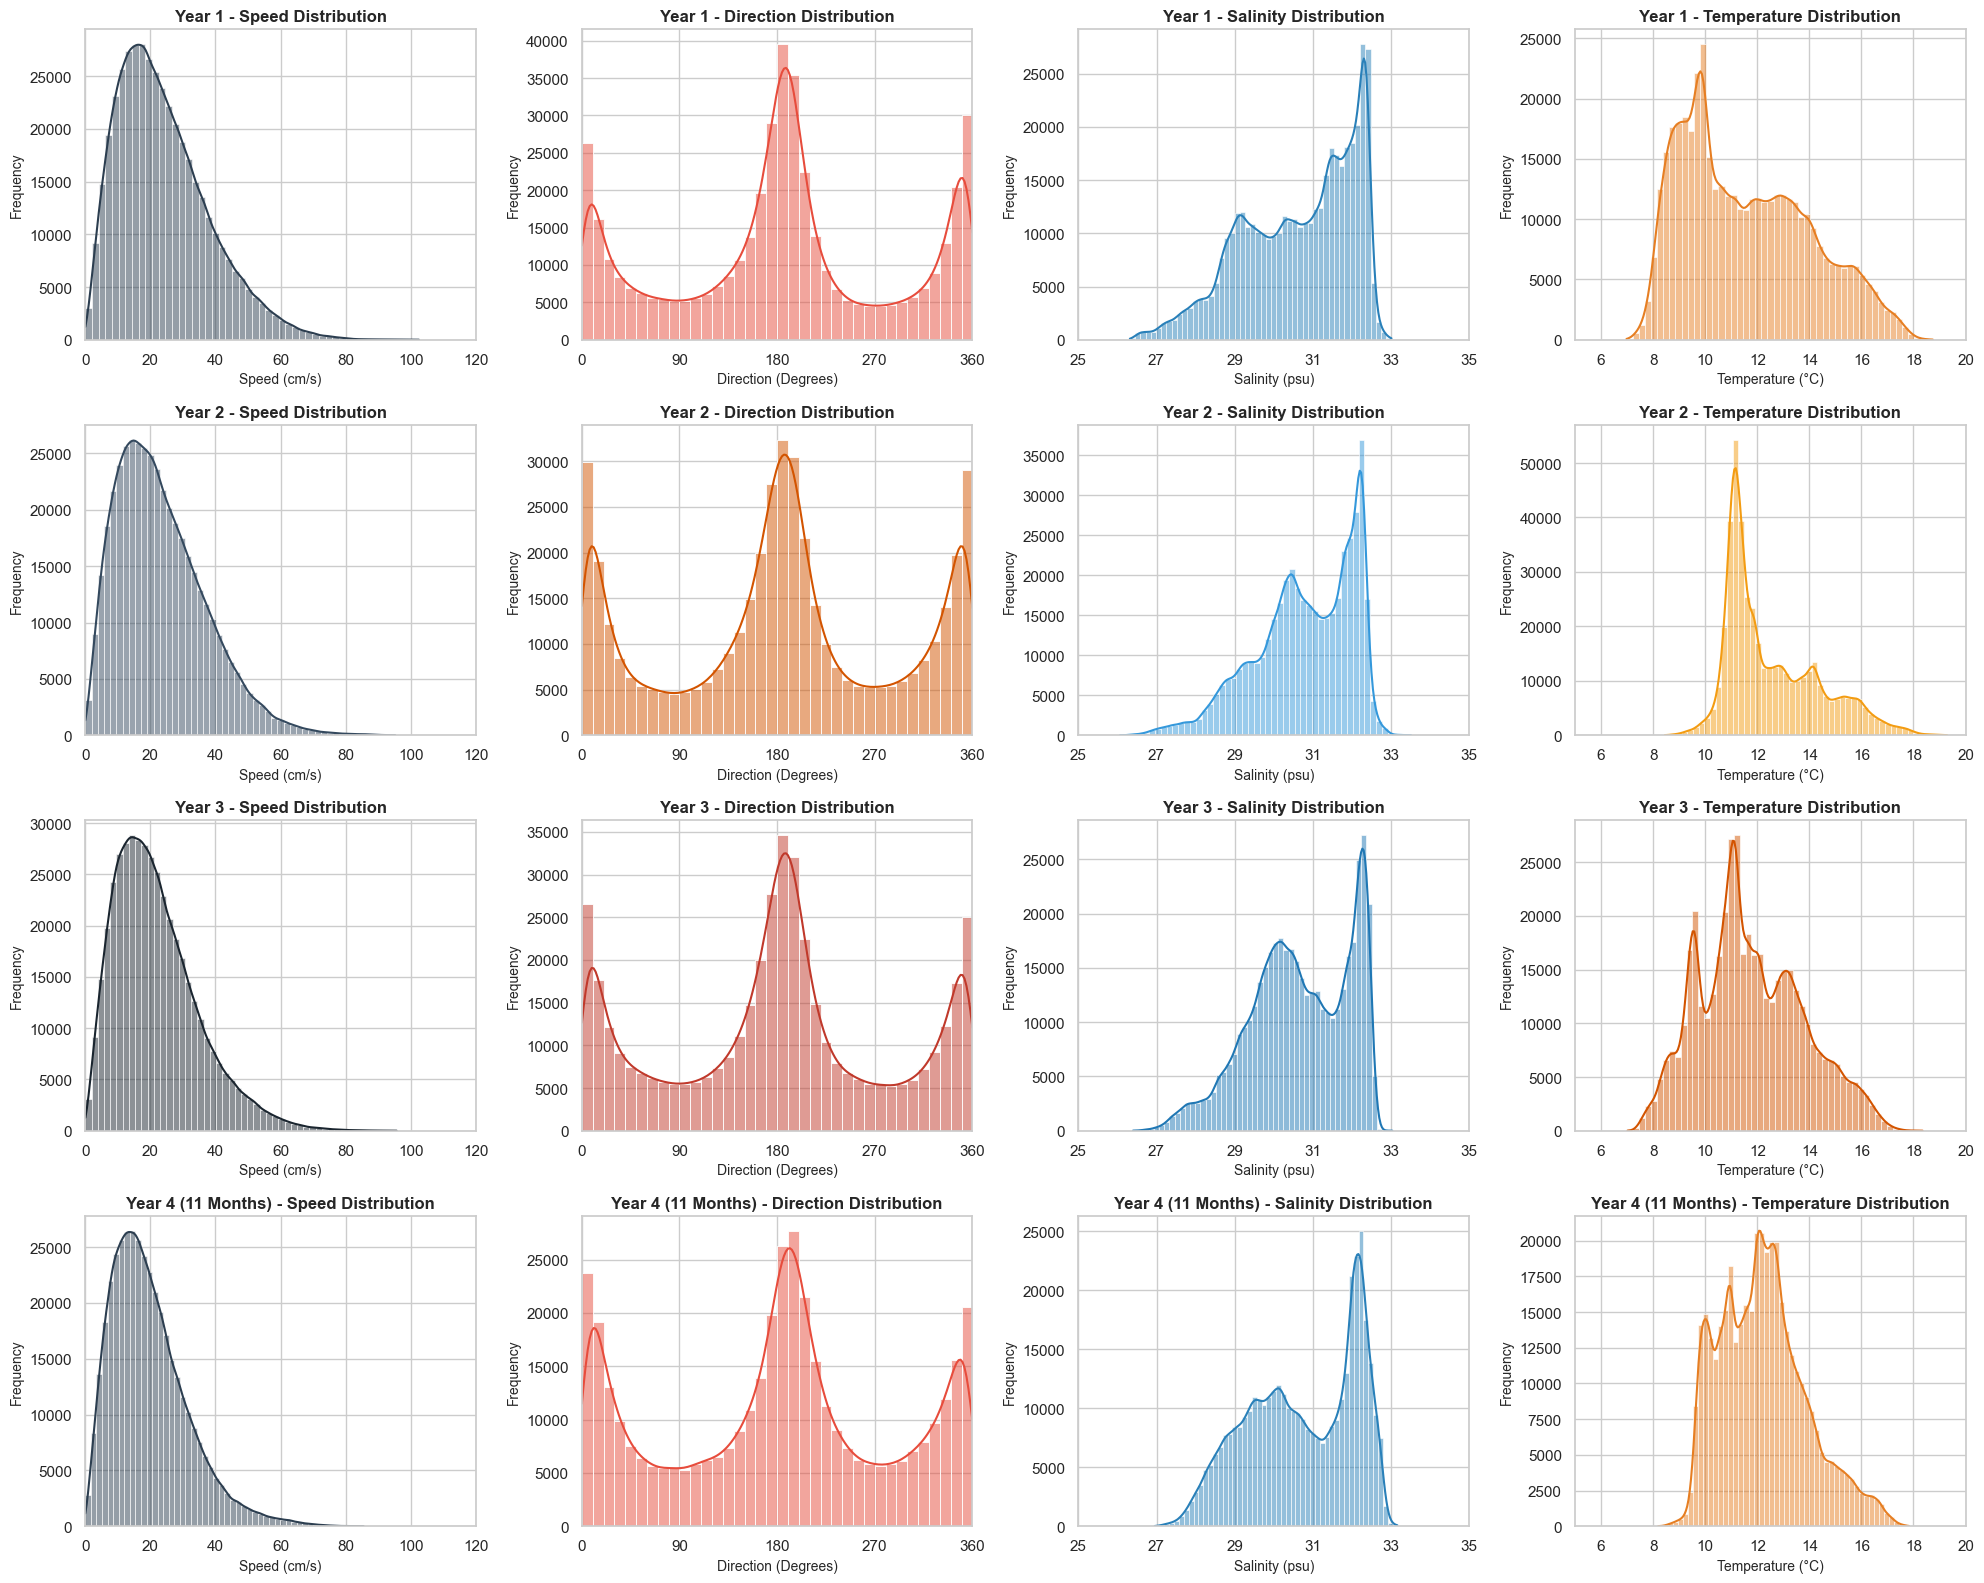

In [9]:
# Set visual style
sns.set_theme(style='whitegrid')

# Create a 4x4 grid of subplots (4 years, 4 variables)
fig, axes = plt.subplots(4, 4, figsize=(20, 16))

colors_speed = ['#2c3e50', '#34495e', '#1a252f', '#2c3e50']
colors_dir = ['#e74c3c', '#d35400', '#c0392b', '#e74c3c']
colors_sal = ['#2980b9', '#3498db', '#1f77b4', '#2980b9']
colors_temp = ['#e67e22', '#f39c12', '#d35400', '#e67e22']

for i, y_df in enumerate(years_dfs):
    year_label = f'Year {i+1}' if i < 3 else 'Year 4 (11 Months)'
    
    # 1. Speed Histograms (Col 1)
    sns.histplot(data=y_df, x='speed_cms', bins=50, kde=True, ax=axes[i, 0], color=colors_speed[i])
    axes[i, 0].set_title(f'{year_label} - Speed Distribution', fontsize=12, fontweight='bold')
    axes[i, 0].set_xlabel('Speed (cm/s)', fontsize=10)
    axes[i, 0].set_ylabel('Frequency', fontsize=10)
    axes[i, 0].set_xlim(0, 110)
    axes[i, 0].set_xticks([0, 20, 40, 60, 80, 100, 120])
    
    # 2. Direction Histograms (Col 2)
    sns.histplot(data=y_df, x='direction', bins=36, kde=True, ax=axes[i, 1], color=colors_dir[i])
    axes[i, 1].set_title(f'{year_label} - Direction Distribution', fontsize=12, fontweight='bold')
    axes[i, 1].set_xlabel('Direction (Degrees)', fontsize=10)
    axes[i, 1].set_ylabel('Frequency', fontsize=10)
    axes[i, 1].set_xlim(0, 360)
    axes[i, 1].set_xticks([0, 90, 180, 270, 360])
    
    # 3. Salinity Histograms (Col 3)
    sns.histplot(data=y_df, x='so', bins=50, kde=True, ax=axes[i, 2], color=colors_sal[i])
    axes[i, 2].set_title(f'{year_label} - Salinity Distribution', fontsize=12, fontweight='bold')
    axes[i, 2].set_xlabel('Salinity (psu)', fontsize=10)
    axes[i, 2].set_ylabel('Frequency', fontsize=10)
    axes[i, 2].set_xlim(25, 35)
    axes[i, 2].set_xticks([25, 27, 29, 31, 33, 35])
    
    # 4. Temperature Histograms (Col 4)
    sns.histplot(data=y_df, x='thetao', bins=50, kde=True, ax=axes[i, 3], color=colors_temp[i])
    axes[i, 3].set_title(f'{year_label} - Temperature Distribution', fontsize=12, fontweight='bold')
    axes[i, 3].set_xlabel('Temperature (°C)', fontsize=10)
    axes[i, 3].set_ylabel('Frequency', fontsize=10)
    axes[i, 3].set_xlim(5, 20)
    axes[i, 3].set_xticks([6, 8, 10, 12, 14, 16, 18, 20])

plt.tight_layout()
plt.show()

### 9. Dataset Duration Verification
Calculates total temporal coverage.

In [10]:
from dateutil.relativedelta import relativedelta

start_date = pd.to_datetime(df['time'].min())
end_date = pd.to_datetime(df['time'].max())
diff = relativedelta(end_date, start_date)

print(f'Start Date: {start_date}')
print(f'End Date:   {end_date}')
print(f'Total Duration: {diff.years} years, {diff.months} months, and {diff.days} days')

Start Date: 2022-07-04 12:00:00
End Date:   2026-06-04 12:00:00
Total Duration: 3 years, 11 months, and 0 days
